<a href="https://colab.research.google.com/github/Angelinat3/Capstone-2026/blob/ai/%5BCAPSTONE%5Dexp_pengembangan_OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import zipfile
import os

zip_file_path = '/content/gdrive/MyDrive/capstone/cord_1000.zip'
extract_dir = '/content/cord_data/'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"File extracted to: {extract_dir}")

File extracted to: /content/cord_data


## Dari Kaggle

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install transformers accelerate sentencepiece timm

from transformers import DonutProcessor, VisionEncoderDecoderModel
import torch
from PIL import Image
import json

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = DonutProcessor.from_pretrained(
    "naver-clova-ix/donut-base-finetuned-cord-v2"
)
model = VisionEncoderDecoderModel.from_pretrained(
    "naver-clova-ix/donut-base-finetuned-cord-v2"
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/335 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/806M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/806M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


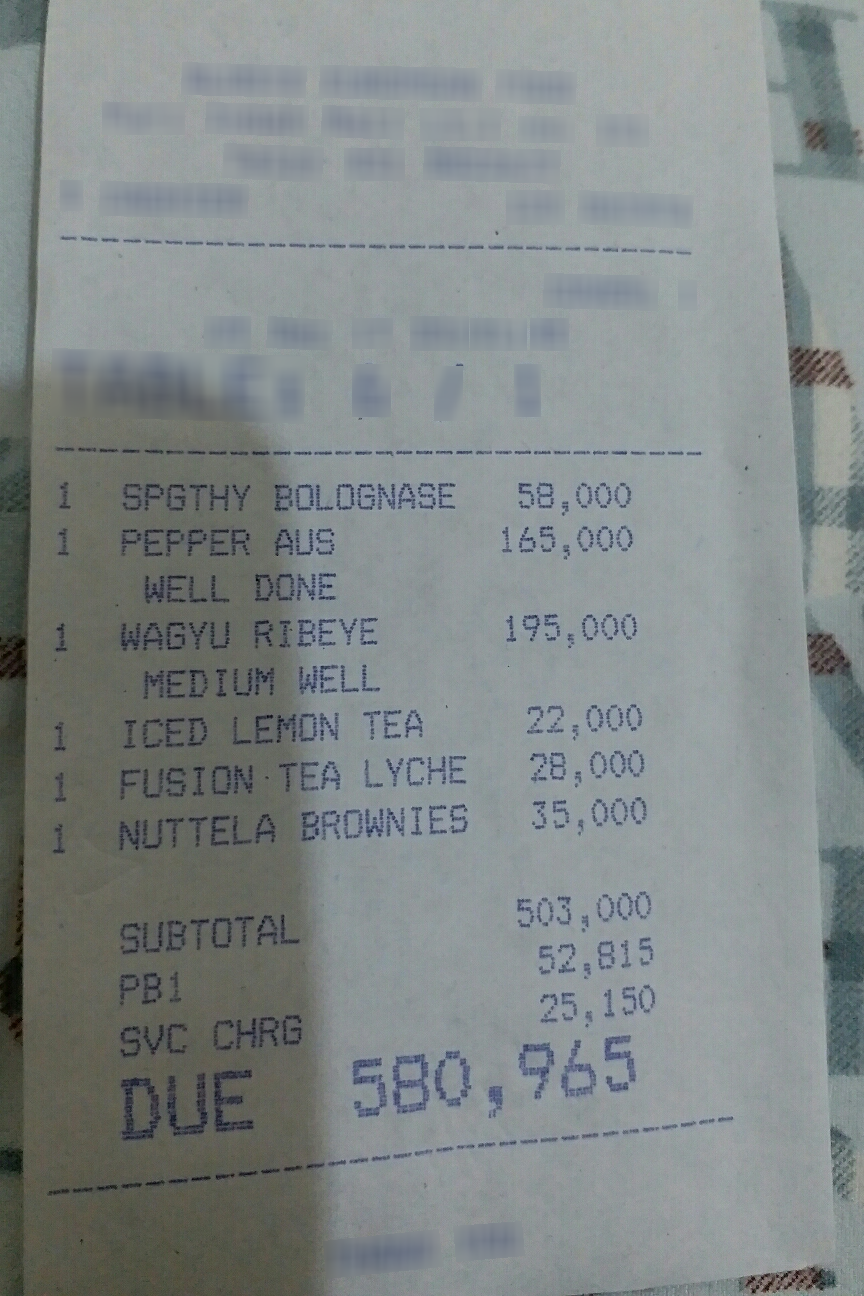

In [ ]:
image_path = "/content/cord_data/CORD/CORD/train/image/receipt_00001.png"   # change to your actual filename

image = Image.open(image_path).convert("RGB")
display(image)


In [ ]:
task_prompt = "<s_cord-v2>"

inputs = processor(
    image,
    task_prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_length=512,
        num_beams=1,        # greedy decoding
        do_sample=False
    )

# ✅ output_ids is already a tensor
sequence = processor.batch_decode(output_ids, skip_special_tokens=True)[0]

# Convert Donut text → JSON
pred_json = processor.token2json(sequence)

#print(json.dumps(pred_json, indent=2, ensure_ascii=False))


In [ ]:
with open("/content/cord_data/CORD/CORD/train/json/receipt_00001.json", "r", encoding="utf-8") as f:
    gt_json = json.load(f)

#print(json.dumps(gt_json, indent=2, ensure_ascii=False))

In [ ]:
import json

with open("/content/cord_data/CORD/CORD/train/json/receipt_00001.json", "r", encoding="utf-8") as f:
    gt_raw = json.load(f)


In [ ]:
def join_words(words):
    return " ".join(w["text"] for w in words)

In [ ]:
from collections import defaultdict

def build_menu_from_gt(gt):
    items = defaultdict(dict)

    for line in gt["valid_line"]:
        cat = line["category"]
        gid = line["group_id"]
        text = join_words(line["words"])

        if cat == "menu.nm":
            items[gid]["nm"] = text
        elif cat == "menu.cnt":
            items[gid]["cnt"] = text
        elif cat == "menu.price":
            items[gid]["price"] = text
        elif cat == "menu.sub_nm":
            items[gid].setdefault("sub", {})["nm"] = text

    # convert to ordered list
    return list(items.values())


In [ ]:
gt_menu = build_menu_from_gt(gt_raw)
gt_menu


[{'cnt': '1', 'nm': 'SPGTHY BOLOGNASE', 'price': '58,000'},
 {'cnt': '1',
  'nm': 'PEPPER AUS',
  'price': '165,000',
  'sub': {'nm': 'WELL DONE'}},
 {'cnt': '1',
  'nm': 'WAGYU RIBEYE',
  'price': '195,000',
  'sub': {'nm': 'MEDIUM WELL'}},
 {'cnt': '1', 'nm': 'ICED LEMON TEA', 'price': '22,000'},
 {'cnt': '1', 'nm': 'FUSION TEA LYCHE', 'price': '28,000'},
 {'cnt': '1', 'nm': 'NUTTELA BROWNIES', 'price': '35,000'}]

In [ ]:
def build_totals_from_gt(gt):
    sub_total = {}
    total = {}

    for line in gt["valid_line"]:
        cat = line["category"]
        text = join_words(line["words"])

        if cat == "sub_total.subtotal_price":
            sub_total["subtotal_price"] = text.replace("SUBTOTAL ", "").strip()
        elif cat == "sub_total.tax_price":
            sub_total["tax_price"] = text.replace(" PB1", "").strip()
        elif cat == "sub_total.service_price":
            sub_total["service_price"] = text.replace("SVC CHRG", "").strip()
        elif cat == "total.total_price":
            total["total_price"] = text.replace("DUE ", "").strip()

    return sub_total, total


In [ ]:
import re

def extract_amount_str(text):
    """
    Text + number se sirf amount ka text nikaalta hai.

    Examples:
      'SUBTOTAL 503,000'         -> '503,000'
      'PB1 144,695'              -> '144,695'
      'Service 100,950'          -> '100,950'
      'TAX 10.00 % 4.364'        -> '4.364'
      'Grand Total 1,591,600'    -> '1,591,600'
      '334,000'                  -> '334,000'
    """
    if text is None:
        return None
    if not isinstance(text, str):
        text = str(text)

    # saare number-like parts nikaalo
    numbers = re.findall(r"\d[\d,\.]*", text)
    if not numbers:
        return None
    # CORD mein amount aam tor pe last number hota hai
    return numbers[-1]

def build_totals_from_gt(gt_raw):
    sub_total = {}
    total = {}

    for line in gt_raw["valid_line"]:
        cat = line["category"]
        raw_text = " ".join(w["text"] for w in line["words"])
        amount = extract_amount_str(raw_text)

        if cat == "sub_total.subtotal_price":
            sub_total["subtotal_price"] = amount
        elif cat == "sub_total.tax_price":
            sub_total["tax_price"] = amount
        elif cat == "sub_total.service_price":
            sub_total["service_price"] = amount
        elif cat == "total.total_price":
            total["total_price"] = amount

    return sub_total, total


In [ ]:
gt_menu = build_menu_from_gt(gt_raw)
gt_sub_total, gt_total = build_totals_from_gt(gt_raw)

gt_structured = {
    "menu": gt_menu,
    "sub_total": gt_sub_total,
    "total": gt_total
}

print(json.dumps(gt_structured, indent=2, ensure_ascii=False))

{
  "menu": [
    {
      "cnt": "1",
      "nm": "SPGTHY BOLOGNASE",
      "price": "58,000"
    },
    {
      "cnt": "1",
      "nm": "PEPPER AUS",
      "price": "165,000",
      "sub": {
        "nm": "WELL DONE"
      }
    },
    {
      "cnt": "1",
      "nm": "WAGYU RIBEYE",
      "price": "195,000",
      "sub": {
        "nm": "MEDIUM WELL"
      }
    },
    {
      "cnt": "1",
      "nm": "ICED LEMON TEA",
      "price": "22,000"
    },
    {
      "cnt": "1",
      "nm": "FUSION TEA LYCHE",
      "price": "28,000"
    },
    {
      "cnt": "1",
      "nm": "NUTTELA BROWNIES",
      "price": "35,000"
    }
  ],
  "sub_total": {
    "subtotal_price": "503,000",
    "tax_price": "1",
    "service_price": "25,150"
  },
  "total": {
    "total_price": "580,965"
  }
}


In [ ]:
gt_sub_total, gt_total = build_totals_from_gt(gt_raw)
gt_sub_total, gt_total


({'subtotal_price': '503,000', 'tax_price': '1', 'service_price': '25,150'},
 {'total_price': '580,965'})

In [ ]:
gt_structured = {
    "menu": gt_menu,
    "sub_total": gt_sub_total,
    "total": gt_total
}

print(json.dumps(gt_structured, indent=2, ensure_ascii=False))


{
  "menu": [
    {
      "cnt": "1",
      "nm": "SPGTHY BOLOGNASE",
      "price": "58,000"
    },
    {
      "cnt": "1",
      "nm": "PEPPER AUS",
      "price": "165,000",
      "sub": {
        "nm": "WELL DONE"
      }
    },
    {
      "cnt": "1",
      "nm": "WAGYU RIBEYE",
      "price": "195,000",
      "sub": {
        "nm": "MEDIUM WELL"
      }
    },
    {
      "cnt": "1",
      "nm": "ICED LEMON TEA",
      "price": "22,000"
    },
    {
      "cnt": "1",
      "nm": "FUSION TEA LYCHE",
      "price": "28,000"
    },
    {
      "cnt": "1",
      "nm": "NUTTELA BROWNIES",
      "price": "35,000"
    }
  ],
  "sub_total": {
    "subtotal_price": "503,000",
    "tax_price": "1",
    "service_price": "25,150"
  },
  "total": {
    "total_price": "580,965"
  }
}


In [ ]:
pred_json["menu"] == gt_structured["menu"]
pred_json["sub_total"] == gt_structured["sub_total"]
pred_json["total"] == gt_structured["total"]


True

In [ ]:
def get_item_count(j):
    try:
        return len(j["menu"])          # list hai, "items" key nahi
    except Exception:
        return None

def get_subtotal(j):
    try:
        return j["sub_total"]["subtotal_price"]
    except Exception:
        return None

def get_tax(j):
    try:
        return j["sub_total"].get("tax_price")
    except Exception:
        return None

def get_service(j):
    try:
        return j["sub_total"].get("service_price")
    except Exception:
        return None

def get_total(j):
    try:
        return j["total"]["total_price"]
    except Exception:
        return None


In [ ]:
def normalize_amount(text):
    """
    extract_amount_str se sirf amount nikaalta hai,
    phir usko integer bana deta hai (commas/dots hata ke).
    """
    amt_str = extract_amount_str(text)
    if amt_str is None:
        return None

    # sirf digits rakhna
    digits = re.sub(r"[^\d]", "", amt_str)
    if digits == "":
        return None

    return int(digits)

In [ ]:
def compare_summary(pred, gt):
    result = {}

    # item count as-is
    pred_items = get_item_count(pred)
    gt_items   = get_item_count(gt)
    #result["item_count_pred"]  = pred_items
    #result["item_count_gt"]    = gt_items
    #result["item_count_match"] = (pred_items == gt_items)

    # subtotal
    pred_sub = get_subtotal(pred)
    gt_sub   = get_subtotal(gt)
    result["subtotal_pred"] = pred_sub
    result["subtotal_gt"]   = gt_sub
    result["subtotal_match"] = (
        normalize_amount(pred_sub) == normalize_amount(gt_sub)
    )

    # tax
    pred_tax = get_tax(pred)
    gt_tax   = get_tax(gt)
    result["tax_pred"] = pred_tax
    result["tax_gt"]   = gt_tax
    #result["tax_match"] = (
    #    normalize_amount(pred_tax) == normalize_amount(gt_tax)
    #)

    # service
    pred_service = get_service(pred)
    gt_service   = get_service(gt)
    result["service_pred"] = pred_service
    result["service_gt"]   = gt_service
    result["service_match"] = (
        normalize_amount(pred_service) == normalize_amount(gt_service)
    )

    # total
    pred_total = get_total(pred)
    gt_total   = get_total(gt)
    result["total_pred"] = pred_total
    result["total_gt"]   = gt_total
    result["total_match"] = (
        normalize_amount(pred_total) == normalize_amount(gt_total)
    )

    # overall summary flag
    result["all_summary_match"] = (
        #result["item_count_match"] and
        result["subtotal_match"] and
        #result["tax_match"] and
        result["service_match"] and
        result["total_match"]
    )

    return result
summary_cmp = compare_summary(pred_json, gt_structured)
summary_cmp

{'subtotal_pred': '503,000',
 'subtotal_gt': '503,000',
 'subtotal_match': True,
 'tax_pred': '52,815',
 'tax_gt': '1',
 'service_pred': '25,150',
 'service_gt': '25,150',
 'service_match': True,
 'total_pred': '580,965',
 'total_gt': '580,965',
 'total_match': True,
 'all_summary_match': True}

In [ ]:
def compare_items(pred, gt):
    pred_items = pred["menu"]
    gt_items   = gt["menu"]

    n = min(len(pred_items), len(gt_items))

    item_results = []
    total_fields = 0
    matched_fields = 0

    for i in range(n):
        p = pred_items[i]
        g = gt_items[i]

        row = {"index": i}

        # name
        row["nm_pred"] = p.get("nm")
        row["nm_gt"]   = g.get("nm")
        row["nm_match"] = (row["nm_pred"] == row["nm_gt"])
        total_fields += 1
        matched_fields += int(row["nm_match"])

        # count
        row["cnt_pred"] = p.get("cnt")
        row["cnt_gt"]   = g.get("cnt")
        row["cnt_match"] = (row["cnt_pred"] == row["cnt_gt"])
        total_fields += 1
        matched_fields += int(row["cnt_match"])

        # price
        row["price_pred"] = p.get("price")
        row["price_gt"]   = g.get("price")
        row["price_match"] = (row["price_pred"] == row["price_gt"])
        total_fields += 1
        matched_fields += int(row["price_match"])

        # sub.nm (optional)
        p_sub = p.get("sub", {}).get("nm")
        g_sub = g.get("sub", {}).get("nm")
        row["sub_nm_pred"] = p_sub
        row["sub_nm_gt"]   = g_sub
        row["sub_nm_match"] = (p_sub == g_sub)
        # count only if at least one side has value
        if p_sub is not None or g_sub is not None:
            total_fields += 1
            matched_fields += int(row["sub_nm_match"])

        item_results.append(row)

    accuracy = matched_fields / total_fields if total_fields > 0 else None
    return item_results, accuracy


In [ ]:
item_results, item_accuracy = compare_items(pred_json, gt_structured)
item_results, item_accuracy


([{'index': 0,
   'nm_pred': 'SPGTHY BOLOGNASE',
   'nm_gt': 'SPGTHY BOLOGNASE',
   'nm_match': True,
   'cnt_pred': '1',
   'cnt_gt': '1',
   'cnt_match': True,
   'price_pred': '58,000',
   'price_gt': '58,000',
   'price_match': True,
   'sub_nm_pred': None,
   'sub_nm_gt': None,
   'sub_nm_match': True},
  {'index': 1,
   'nm_pred': 'PEPPER AUS',
   'nm_gt': 'PEPPER AUS',
   'nm_match': True,
   'cnt_pred': '1',
   'cnt_gt': '1',
   'cnt_match': True,
   'price_pred': '165,000',
   'price_gt': '165,000',
   'price_match': True,
   'sub_nm_pred': 'WELL DONE',
   'sub_nm_gt': 'WELL DONE',
   'sub_nm_match': True},
  {'index': 2,
   'nm_pred': 'WAGYU RIBEYE',
   'nm_gt': 'WAGYU RIBEYE',
   'nm_match': True,
   'cnt_pred': '1',
   'cnt_gt': '1',
   'cnt_match': True,
   'price_pred': '195,000',
   'price_gt': '195,000',
   'price_match': True,
   'sub_nm_pred': 'MEDIUM WELL',
   'sub_nm_gt': 'MEDIUM WELL',
   'sub_nm_match': True},
  {'index': 3,
   'nm_pred': 'ICED LEMON TEA',
   'nm_

In [ ]:
from collections import defaultdict
import json

# ---------- GT helpers ----------

def join_words(words):
    return " ".join(w["text"] for w in words)

def build_menu_from_gt(gt_raw):
    items = defaultdict(dict)
    for line in gt_raw["valid_line"]:
        cat = line["category"]
        gid = line["group_id"]
        text = join_words(line["words"])

        if cat == "menu.nm":
            items[gid]["nm"] = text
        elif cat == "menu.cnt":
            items[gid]["cnt"] = text
        elif cat == "menu.price":
            items[gid]["price"] = text
        elif cat == "menu.sub_nm":
            items[gid].setdefault("sub", {})["nm"] = text
    return list(items.values())

def build_totals_from_gt(gt_raw):
    sub_total = {}
    total = {}
    for line in gt_raw["valid_line"]:
        cat = line["category"]
        text = join_words(line["words"])

        if cat == "sub_total.subtotal_price":
            sub_total["subtotal_price"] = text
        elif cat == "sub_total.tax_price":
            sub_total["tax_price"] = text
        elif cat == "sub_total.service_price":
            sub_total["service_price"] = text
        elif cat == "total.total_price":
            total["total_price"] = text
    return sub_total, total

def build_structured_gt(gt_raw):
    menu = build_menu_from_gt(gt_raw)
    sub_total, total = build_totals_from_gt(gt_raw)
    return {
        "menu": menu,
        "sub_total": sub_total,
        "total": total,
    }


In [ ]:
# ---------- summary comparison ----------

def get_item_count(j):
    try:
        return len(j["menu"])
    except Exception:
        return None

def get_subtotal(j):
    try:
        return j["sub_total"]["subtotal_price"]
    except Exception:
        return None

def get_tax(j):
    try:
        return j["sub_total"].get("tax_price")
    except Exception:
        return None

def get_service(j):
    try:
        return j["sub_total"].get("service_price")
    except Exception:
        return None

def get_total(j):
    try:
        return j["total"]["total_price"]
    except Exception:
        return None

def compare_summary(pred, gt):
    result = {}

    # item count as-is
    pred_items = get_item_count(pred)
    gt_items   = get_item_count(gt)
    #result["item_count_pred"]  = pred_items
    #result["item_count_gt"]    = gt_items
    #result["item_count_match"] = (pred_items == gt_items)

    # subtotal
    raw_pred_sub = get_subtotal(pred)
    raw_gt_sub   = get_subtotal(gt)

    clean_pred_sub = extract_amount_str(raw_pred_sub)
    clean_gt_sub   = extract_amount_str(raw_gt_sub)

    result["subtotal_pred"] = clean_pred_sub
    result["subtotal_gt"]   = clean_gt_sub
    result["subtotal_match"] = (
        normalize_amount(clean_pred_sub) == normalize_amount(clean_gt_sub)
    )

    # tax
    raw_pred_tax = get_tax(pred)
    raw_gt_tax   = get_tax(gt)

    clean_pred_tax = extract_amount_str(raw_pred_tax)
    clean_gt_tax   = extract_amount_str(raw_gt_tax)

    #result["tax_pred"] = clean_pred_tax
    #result["tax_gt"]   = clean_gt_tax
    #result["tax_match"] = (
    #    normalize_amount(clean_pred_tax) == normalize_amount(clean_gt_tax)
    #)

    # service
    raw_pred_service = get_service(pred)
    raw_gt_service   = get_service(gt)

    clean_pred_service = extract_amount_str(raw_pred_service)
    clean_gt_service   = extract_amount_str(raw_gt_service)

    result["service_pred"] = clean_pred_service
    result["service_gt"]   = clean_gt_service
    result["service_match"] = (
        normalize_amount(clean_pred_service) == normalize_amount(clean_gt_service)
    )

    # total
    raw_pred_total = get_total(pred)
    raw_gt_total   = get_total(gt)

    clean_pred_total = extract_amount_str(raw_pred_total)
    clean_gt_total   = extract_amount_str(raw_gt_total)

    result["total_pred"] = clean_pred_total
    result["total_gt"]   = clean_gt_total
    result["total_match"] = (
        normalize_amount(clean_pred_total) == normalize_amount(clean_gt_total)
    )

    # overall summary flag
    result["all_summary_match"] = (
        #result["item_count_match"] and
        result["subtotal_match"] and
        #result["tax_match"] and
        result["service_match"] and
        result["total_match"]
    )

    return result



In [ ]:
# ---------- item comparison ----------

def compare_items(pred, gt):
    pred_items = pred["menu"]
    gt_items   = gt["menu"]

    n = min(len(pred_items), len(gt_items))

    item_results = []
    total_fields = 0
    matched_fields = 0

    for i in range(n):
        p = pred_items[i]
        g = gt_items[i]

        row = {"index": i}

        # name
        row["nm_pred"] = p.get("nm")
        row["nm_gt"]   = g.get("nm")
        row["nm_match"] = (row["nm_pred"] == row["nm_gt"])
        total_fields += 1
        matched_fields += int(row["nm_match"])

        # count
        row["cnt_pred"] = p.get("cnt")
        row["cnt_gt"]   = g.get("cnt")
        row["cnt_match"] = (row["cnt_pred"] == row["cnt_gt"])
        total_fields += 1
        matched_fields += int(row["cnt_match"])

        # price
        row["price_pred"] = p.get("price")
        row["price_gt"]   = g.get("price")
        row["price_match"] = (row["price_pred"] == row["price_gt"])
        total_fields += 1
        matched_fields += int(row["price_match"])

        # sub.nm (optional)
        p_sub = p.get("sub", {}).get("nm")
        g_sub = g.get("sub", {}).get("nm")
        row["sub_nm_pred"] = p_sub
        row["sub_nm_gt"]   = g_sub
        row["sub_nm_match"] = (p_sub == g_sub)
        if p_sub is not None or g_sub is not None:
            total_fields += 1
            matched_fields += int(row["sub_nm_match"])

        item_results.append(row)

    accuracy = matched_fields / total_fields if total_fields > 0 else None
    return item_results, accuracy


In [ ]:
from PIL import Image
import torch
import json

def run_donut_on_image(image_path, processor, model, device="cpu"):
    image = Image.open(image_path).convert("RGB")

    task_prompt = "<s_cord-v2>"

    inputs = processor(
        image,
        task_prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=512,
            num_beams=1,
            do_sample=False,
        )

    sequence = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    pred_json = processor.token2json(sequence)
    return pred_json


In [ ]:
from collections import defaultdict
import re

def join_words(words):
    return " ".join(w["text"] for w in words)

def extract_amount_str(text):
    """
    Text + number se sirf amount ka text nikaalta hai.

    Examples:
      'SUBTOTAL 503,000'         -> '503,000'
      'PB1 144,695'              -> '144,695'
      'Service 100,950'          -> '100,950'
      'TAX 10.00 % 4.364'        -> '4.364'
      'Grand Total 1,591,600'    -> '1,591,600'
      '334,000'                  -> '334,000'
    """
    if text is None:
        return None
    if not isinstance(text, str):
        text = str(text)

    # saare number-like parts nikaalo
    numbers = re.findall(r"\d[\d,\.]*", text)
    if not numbers:
        return None
    # CORD mein amount aam tor pe last number hota hai
    return numbers[-1]

def normalize_amount(text):
    """
    extract_amount_str se sirf amount nikaalta hai,
    phir usko float bana deta hai (commas/dots hata ke).
    """
    if text is None:
        return 0.0
    amt_str = extract_amount_str(text)
    if amt_str is None:
        return 0.0

    # For CORD, assume comma is thousands separator, or simply remove them for parsing.
    # And convert to float directly.
    if amt_str:
        cleaned_num = amt_str.replace(",", "") # Remove thousands separators
        try:
            return float(cleaned_num)
        except ValueError:
            pass
    return 0.0 # Return 0.0 if unable to convert

def build_structured_output(gt_raw):
    structured_data = {
        "merchant": {
            "name": "", "address": "", "phone": "", "npwp": ""
        },
        "transaction": {
            "receipt_number": "", "date": "", "time": "", "cashier_name": ""
        },
        "items": [],
        "summary": {
            "subtotal": 0.0, "total_discount": 0.0, "tax_ppn": 0.0,
            "service_charge": 0.0, "grand_total": 0.0
        },
        "payment": {
            "method": "", "amount_paid": 0.0, "change": 0.0
        },
        "metadata": {
            "category": "Uncategorized", "confidence_score": 0.0
        }
    }

    menu_items_grouped = defaultdict(dict)
    temp_summary = {}

    for line in gt_raw["valid_line"]:
        cat = line["category"]
        text = join_words(line["words"])

        # Merchant information (mapping CORD categories)
        if cat == "company.name":
            structured_data["merchant"]["name"] = text
        elif cat == "company.address":
            structured_data["merchant"]["address"] = text
        elif cat == "company.tel":
            structured_data["merchant"]["phone"] = text
        elif cat == "company.vat_id": # CORD uses vat_id for tax ID, can map to NPWP
            structured_data["merchant"]["npwp"] = text

        # Transaction information
        elif cat == "receipt_no": # Common category for receipt number
            structured_data["transaction"]["receipt_number"] = text
        elif cat == "date.issue": # Date of transaction
            structured_data["transaction"]["date"] = text
        elif cat == "time.issue": # Time of transaction
            structured_data["transaction"]["time"] = text
        elif cat == "cashier": # Cashier name (if available)
            structured_data["transaction"]["cashier_name"] = text

        # Menu items
        gid = line.get("group_id")
        if gid is not None:
            if cat == "menu.nm":
                menu_items_grouped[gid]["nm"] = text
            elif cat == "menu.cnt":
                menu_items_grouped[gid]["cnt"] = text
            elif cat == "menu.price":
                menu_items_grouped[gid]["price"] = text
            elif cat == "menu.sub_nm":
                menu_items_grouped[gid].setdefault("sub", {})["nm"] = text

        # Summary information (temporarily store raw text, normalize later)
        elif cat == "sub_total.subtotal_price":
            temp_summary["subtotal"] = text
        elif cat == "sub_total.tax_price":
            temp_summary["tax_ppn"] = text
        elif cat == "sub_total.service_price":
            temp_summary["service_charge"] = text
        elif cat == "total.total_price":
            temp_summary["grand_total"] = text

    # Populate 'items' list from grouped menu items
    for gid in sorted(menu_items_grouped.keys()):
        item_data = menu_items_grouped[gid]
        item_name = item_data.get("nm", "")
        quantity_raw = item_data.get("cnt", "1")
        total_price_raw = item_data.get("price", "0")

        quantity = normalize_amount(quantity_raw)
        total_price = normalize_amount(total_price_raw)
        unit_price = total_price / quantity if quantity > 0 else 0.0

        structured_data["items"].append({
            "item_name": item_name,
            "quantity": quantity,
            "unit_price": unit_price,
            "total_price": total_price,
            "discount_amount": 0.0 # Not directly available per item in CORD, defaulting to 0.0
        })

    # Populate 'summary' with normalized float values
    structured_data["summary"]["subtotal"] = normalize_amount(temp_summary.get("subtotal"))
    structured_data["summary"]["tax_ppn"] = normalize_amount(temp_summary.get("tax_ppn"))
    structured_data["summary"]["service_charge"] = normalize_amount(temp_summary.get("service_charge"))
    structured_data["summary"]["grand_total"] = normalize_amount(temp_summary.get("grand_total"))
    structured_data["summary"]["total_discount"] = 0.0 # Not directly available in CORD

    # Payment details (not explicitly available in CORD 'valid_line' for structured extraction, using defaults)
    structured_data["payment"]["method"] = "UNKNOWN"
    structured_data["payment"]["amount_paid"] = structured_data["summary"]["grand_total"]
    structured_data["payment"]["change"] = 0.0

    # Metadata (not explicitly available in CORD 'valid_line' for category or confidence_score, using defaults)
    structured_data["metadata"]["category"] = "Receipt"
    structured_data["metadata"]["confidence_score"] = 1.0

    return structured_data


In [ ]:
def get_item_count(j):
    try:
        return len(j["menu"])
    except Exception:
        return None

def get_subtotal(j):
    try:
        return j["sub_total"]["subtotal_price"]
    except Exception:
        return None

def get_tax(j):
    try:
        return j["sub_total"].get("tax_price")
    except Exception:
        return None

def get_service(j):
    try:
        return j["sub_total"].get("service_price")
    except Exception:
        return None

def get_total(j):
    try:
        return j["total"]["total_price"]
    except Exception:
        return None

def compare_summary(pred, gt):
    result = {}

    #pred_items = get_item_count(pred)
    #gt_items   = get_item_count(gt)
    #result["item_count_pred"]  = pred_items
    #result["item_count_gt"]    = gt_items
    #result["item_count_match"] = (pred_items == gt_items)

    pred_sub = get_subtotal(pred)
    gt_sub   = get_subtotal(gt)
    result["subtotal_pred"]   = pred_sub
    result["subtotal_gt"]     = gt_sub
    result["subtotal_match"]  = (pred_sub == gt_sub)

    pred_tax = get_tax(pred)
    gt_tax   = get_tax(gt)
    result["tax_pred"]   = pred_tax
    result["tax_gt"]     = gt_tax
    #result["tax_match"]  = (pred_tax == gt_tax)

    pred_service = get_service(pred)
    gt_service   = get_service(gt)
    result["service_pred"]   = pred_service
    result["service_gt"]     = gt_service
    result["service_match"]  = (pred_service == gt_service)

    pred_total = get_total(pred)
    gt_total   = get_total(gt)
    result["total_pred"]   = pred_total
    result["total_gt"]     = gt_total
    result["total_match"]  = (pred_total == gt_total)

    result["all_summary_match"] = (
        #result["item_count_match"] and
        result["subtotal_match"] and
        #result["tax_match"] and
        result["service_match"] and
        result["total_match"]
    )

    return result


def compare_items(pred, gt):
    pred_items = normalize_menu(pred)
    gt_items   = normalize_menu(gt)

    n = min(len(pred_items), len(gt_items))

    item_results = []
    total_fields = 0
    matched_fields = 0

    for i in range(n):
        p = pred_items[i]
        g = gt_items[i]

        row = {"index": i}

        # name
        row["nm_pred"] = p.get("nm")
        row["nm_gt"]   = g.get("nm")
        row["nm_match"] = (row["nm_pred"] == row["nm_gt"])
        total_fields += 1
        matched_fields += int(row["nm_match"])

        # count
        row["cnt_pred"] = p.get("cnt")
        row["cnt_gt"]   = g.get("cnt")
        row["cnt_match"] = (row["cnt_pred"] == row["cnt_gt"])
        total_fields += 1
        matched_fields += int(row["cnt_match"])

        # price
        row["price_pred"] = p.get("price")
        row["price_gt"]   = g.get("price")
        row["price_match"] = (row["price_pred"] == row["price_gt"])
        total_fields += 1
        matched_fields += int(row["price_match"])

        # sub.nm (optional)
        p_sub = p.get("sub", {}).get("nm")
        g_sub = g.get("sub", {}).get("nm")
        row["sub_nm_pred"] = p_sub
        row["sub_nm_gt"]   = g_sub
        row["sub_nm_match"] = (p_sub == g_sub)
        if p_sub is not None or g_sub is not None:
            total_fields += 1
            matched_fields += int(row["sub_nm_match"])

        item_results.append(row)

    accuracy = matched_fields / total_fields if total_fields > 0 else None
    return item_results, accuracy


In [ ]:
def evaluate_single_sample(image_path, gt_json_path, processor, model, device="cpu"):
    # 1) prediction
    pred_json = run_donut_on_image(image_path, processor, model, device=device)

    # 2) GT load + structure
    with open(gt_json_path, "r", encoding="utf-8") as f:
        gt_raw = json.load(f)
    gt_structured = build_structured_gt(gt_raw)

    # 3) comparisons
    summary_cmp = compare_summary(pred_json, gt_structured)
    item_results, item_acc = compare_items(pred_json, gt_structured)

    return {
        "image_path": image_path,
        "gt_path": gt_json_path,
        "summary_cmp": summary_cmp,
        "item_results": item_results,
        "item_accuracy": item_acc,
    }


In [ ]:
import os

image_dir = "/content/cord_data/CORD/CORD/train/image"
json_dir  = "/content/cord_data/CORD/CORD/train/json"

pairs = []

for file in sorted(os.listdir(image_dir)):
    if file.endswith(".png"):
        img_path = os.path.join(image_dir, file)
        json_path = os.path.join(json_dir, file.replace(".png", ".json"))

        if os.path.exists(json_path):
            pairs.append((img_path, json_path))

# sanity check
print("Total pairs:", len(pairs))
print(pairs[:3])

Total pairs: 800
[('/content/cord_data/CORD/CORD/train/image/receipt_00000.png', '/content/cord_data/CORD/CORD/train/json/receipt_00000.json'), ('/content/cord_data/CORD/CORD/train/image/receipt_00001.png', '/content/cord_data/CORD/CORD/train/json/receipt_00001.json'), ('/content/cord_data/CORD/CORD/train/image/receipt_00002.png', '/content/cord_data/CORD/CORD/train/json/receipt_00002.json')]


In [ ]:
# Example:
# pairs = [
#   ("/content/images/1.jpg", "/content/labels/1.json"),
#   ("/content/images/2.jpg", "/content/labels/2.json"),
#   ...
# ]

def evaluate_dataset(pairs, processor, model, device="cpu", max_samples=None):
    results = []
    n = len(pairs) if max_samples is None else min(len(pairs), max_samples)

    for i in range(n):
        img_path, gt_path = pairs[i]
        print(f"[{i+1}/{n}] Evaluating:", img_path)
        res = evaluate_single_sample(img_path, gt_path, processor, model, device=device)
        results.append(res)

    # ---- compute metrics ----
    num_samples = len(results)
    if num_samples == 0:
        return {
            "results": results,
            "summary_accuracy": None,
            "mean_item_accuracy": None,
            "overall_accuracy": None,
        }

    # summary_accuracy: fraction of receipts with perfect summary
    summary_correct = sum(1 for r in results if r["summary_cmp"]["all_summary_match"])
    summary_accuracy = summary_correct / num_samples

    # mean item_accuracy across samples
    item_acc_sum = 0.0
    valid_item_acc_count = 0
    for r in results:
        acc = r["item_accuracy"]
        if acc is not None:
            item_acc_sum += acc
            valid_item_acc_count += 1
    mean_item_accuracy = (item_acc_sum / valid_item_acc_count) if valid_item_acc_count > 0 else None

    # overall_accuracy: summary perfect AND item_accuracy == 1.0
    overall_correct = sum(
        1 for r in results
        if r["summary_cmp"]["all_summary_match"] and r["item_accuracy"] == 1.0
    )
    overall_accuracy = overall_correct / num_samples

    return {
        "results": results,
        "summary_accuracy": summary_accuracy,
        "mean_item_accuracy": mean_item_accuracy,
        "overall_accuracy": overall_accuracy,
    }


In [ ]:
def normalize_menu(j):
    """
    Ensure j["menu"] is always a list of item dicts.
    """
    if "menu" not in j or j["menu"] is None:
        return []

    menu = j["menu"]

    # Case 1: already correct
    if isinstance(menu, list):
        return menu

    # Case 2: single item dict
    if isinstance(menu, dict):
        # sometimes Donut wraps items again
        if "items" in menu and isinstance(menu["items"], list):
            return menu["items"]
        else:
            return [menu]

    # fallback
    return []


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

eval_out = evaluate_dataset(pairs, processor, model, device=device, max_samples=10)
print("Summary Accuracy: ", eval_out["summary_accuracy"])
print("Item Accuracy: ", eval_out["mean_item_accuracy"])
print("Overall Accuracy: ", eval_out["overall_accuracy"])



[1/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00000.png
[2/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00001.png
[3/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00002.png
[4/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00003.png
[5/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00004.png
[6/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00005.png
[7/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00006.png
[8/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00007.png
[9/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00008.png
[10/10] Evaluating: /content/cord_data/CORD/CORD/train/image/receipt_00009.png
Summary Accuracy:  0.0
Item Accuracy:  0.95
Overall Accuracy:  0.0


In [ ]:
for i, r in enumerate(eval_out["results"]):
    print(f"\n===== SAMPLE {i} =====")
    print("Summary comparison:")
    for k, v in r["summary_cmp"].items():
        print(f"  {k}: {v}")



===== SAMPLE 0 =====
Summary comparison:
  subtotal_pred: 1,346,000
  subtotal_gt: Sub-Total 1,346,000
  subtotal_match: False
  tax_pred: 144,695
  tax_gt: PB1 144,695
  service_pred: 100,950
  service_gt: Service 100,950
  service_match: False
  total_pred: 1,591,600
  total_gt: Grand Total 1,591,600
  total_match: False
  all_summary_match: False

===== SAMPLE 1 =====
Summary comparison:
  subtotal_pred: 503,000
  subtotal_gt: SUBTOTAL 503,000
  subtotal_match: False
  tax_pred: 52,815
  tax_gt: 52,815 PB1
  service_pred: 25,150
  service_gt: SVC CHRG 25,150
  service_match: False
  total_pred: 580,965
  total_gt: DUE 580,965
  total_match: False
  all_summary_match: False

===== SAMPLE 2 =====
Summary comparison:
  subtotal_pred: 334,000
  subtotal_gt: Subtotal 334,000
  subtotal_match: False
  tax_pred: None
  tax_gt: None
  service_pred: None
  service_gt: None
  service_match: True
  total_pred: 334,000
  total_gt: Total 334,000
  total_match: False
  all_summary_match: False



In [ ]:
!pip install pytesseract

In [ ]:
import pytesseract
from PIL import Image
import spacy

# Load image
img = Image.open('/content/cord_data/CORD/CORD/train/image/receipt_00001.png')
text = pytesseract.image_to_string(img)

# Extract entities
nlp = spacy.load('en_core_web_sm')
doc = nlp(text)
for ent in doc.ents:
    if ent.label_ == 'DUE':
        print(f"Amount: {ent.text}")
    if ent.label_ == 'ORG':
        print(f"Merchant: {ent.text}")

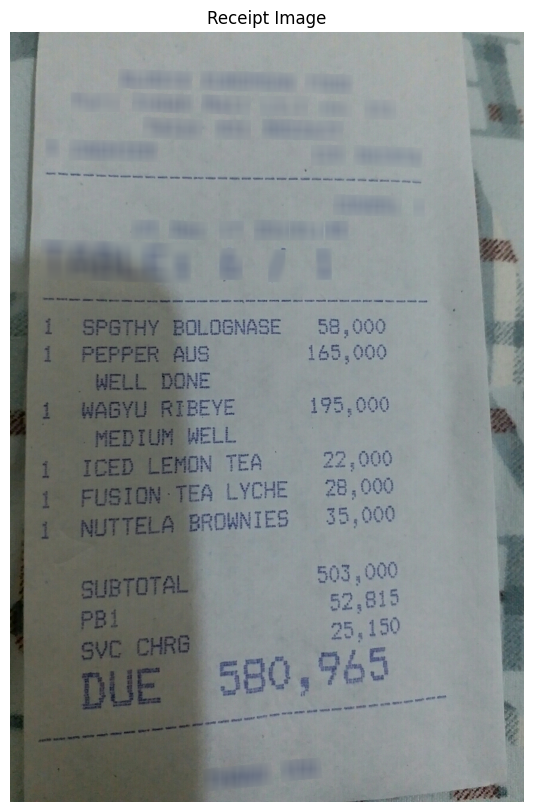

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Load and display the image
img = Image.open('/content/cord_data/CORD/CORD/train/image/receipt_00001.png')

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.title("Receipt Image")
plt.show()



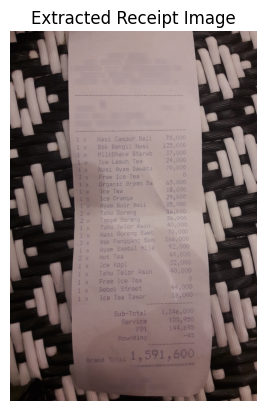

Extracted Amounts:
75,000
125,000
70,000
3
2
2
1
3
2
1
1
1
100,950
144,695
1
591,600


In [ ]:
# Step 1: Install EasyOCR (if not already installed)
!pip install easyocr --quiet

# Step 2: Import Libraries
import easyocr
from matplotlib import pyplot as plt
from PIL import Image

# Step 3: Load the image
image_path = "/content/cord_data/CORD/CORD/train/image/receipt_00000.png"  # Use your actual image path

# Step 4: Initialize EasyOCR reader
reader = easyocr.Reader(['en'])

# Step 5: Perform OCR
results = reader.readtext(image_path)

# Step 6: Extract only amounts (numbers with commas or digits)
import re

amounts = []
for bbox, text, conf in results:
    if re.match(r'^\d{1,3}(,\d{3})*(\.\d+)?$', text.strip()):
        amounts.append(text.strip())

# Step 7: Show the image and amounts
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title("Extracted Receipt Image")
plt.show()

#print(results)

# Display the extracted amounts
print("Extracted Amounts:")
for amt in amounts:
    print(amt)


In [ ]:
!pip install -U "transformers" "accelerate" "safetensors" --quiet
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
!pip install fastapi --quiet
import fastapi
print(fastapi.__version__)


0.135.3


In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel
from PIL import Image
import torch

# model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"
model_name = "naver-clova-ix/donut-base"

processor = DonutProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)


device = torch.device("cpu")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.eval()
print(device)

# Load your invoice image
image = Image.open("/content/cobaah.png").convert("RGB")


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


cpu


In [ ]:
import pytesseract
from PIL import Image
import spacy
import pandas as pd
import json
import os
from pathlib import Path

# Configure Tesseract path (update if needed for your system)
# For Windows: pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# Load spaCy model for NLP
nlp = spacy.load('en_core_web_sm')

def preprocess_image(image_path):
    """Preprocess image for better OCR accuracy."""
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize((int(img.width * 2), int(img.height * 2)))  # Increase resolution
    return img

def extract_text(image_path):
    """Extract text from receipt image using Tesseract."""
    try:
        img = preprocess_image(image_path)
        text = pytesseract.image_to_string(img, config='--psm 6')  # PSM 6 for block of text
        return text
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return ""

def parse_receipt(text):
    """Parse extracted text to identify amounts, merchants, and dates."""
    doc = nlp(text)
    extracted_data = {'amount': None, 'merchant': None, 'date': None}

    for ent in doc.ents:
        if ent.label_ == 'MONEY' and not extracted_data['amount']:
            extracted_data['amount'] = ent.text
        elif ent.label_ == 'ORG' and not extracted_data['merchant']:
            extracted_data['merchant'] = ent.text
        elif ent.label_ == 'DATE' and not extracted_data['date']:
            extracted_data['date'] = ent.text

    return extracted_data

def load_json_annotation(json_path):
    """Load JSON annotation for a receipt."""
    try:
        with open(json_path, 'r') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {json_path}: {e}")
        return {}

def map_to_category(description, annotations=None):
    """Map description to category (placeholder; use annotations if available)."""
    # Placeholder: Use annotations['items'] or train a classifier
    if annotations and 'items' in annotations:
        # Example: Take first item's category if available
        for item in annotations.get('items', []):
            if 'category' in item:
                return item['category']
    return 'Uncategorized'

def process_receipt(image_path, json_path, base_path):
    """Process a receipt image and its JSON annotation."""
    # Extract text from image
    text = extract_text(image_path)

    # Parse entities
    extracted_data = parse_receipt(text)

    # Load JSON annotation
    annotations = load_json_annotation(json_path)

    # Update extracted data with JSON annotations (if available)
    if annotations:
        extracted_data['amount'] = annotations.get('total', extracted_data['amount'])
        extracted_data['merchant'] = annotations.get('merchant', extracted_data['merchant'])
        extracted_data['date'] = annotations.get('date', extracted_data['date'])

    # Map to category
    extracted_data['category'] = map_to_category(text, annotations)

    return extracted_data

def process_cord_dataset(base_path, split='train', max_receipts=10):
    """Process receipts from CORD-1000 dataset."""
    image_dir = Path(base_path) / split / 'image'
    json_dir = Path(base_path) / split / 'json'

    if not image_dir.exists() or not json_dir.exists():
        print(f"Error: {image_dir} or {json_dir} not found.")
        return []

    results = []
    for i, json_file in enumerate(sorted(json_dir.glob('receipt_*.json'))):
        if i >= max_receipts:  # Limit for testing
            break
        image_file = image_dir / json_file.name.replace('.json', '.png')  # Assume PNG; adjust if JPG
        if image_file.exists():
            result = process_receipt(image_file, json_file, base_path)
            results.append(result)
            print(f"Processed {json_file.name}: {result}")
        else:
            print(f"Image not found for {json_file.name}")

    return results

# Example usage
if __name__ == '__main__':
    # Replace with your CORD-1000 dataset path
    dataset_path = '/content/cord_data/CORD/CORD'
    try:
        results = process_cord_dataset(dataset_path, split='train', max_receipts=5)
        # Save results as JSON
        with open('extracted_receipts.json', 'w') as f:
            json.dump(results, f, indent=2)
        print("Results saved to extracted_receipts.json")
    except Exception as e:
        print(f"Error: {e}")

Processed receipt_00000.json: {'amount': None, 'merchant': None, 'date': '1591', 'category': 'Uncategorized'}
Processed receipt_00001.json: {'amount': None, 'merchant': 'AUS 165,000 7\nINE', 'date': None, 'category': 'Uncategorized'}
Processed receipt_00002.json: {'amount': None, 'merchant': 'CRISPY', 'date': None, 'category': 'Uncategorized'}
Processed receipt_00003.json: {'amount': None, 'merchant': 'Chicken H-H', 'date': None, 'category': 'Uncategorized'}
Processed receipt_00004.json: {'amount': None, 'merchant': 'BIHIM', 'date': '4', 'category': 'Uncategorized'}
Results saved to extracted_receipts.json


In [ ]:
!pip install pytesseract pillow spacy pandas

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel


#device = torch.device("cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# change this to your chosen model
# example: invoice model or cord model
model_name = "naver-clova-ix/donut-base-finetuned-cord-v2"  # or your own fine tuned model

processor = DonutProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)
model.to(device)
model.eval()


Using device: cuda


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

In [ ]:
from PIL import Image
import io

def bytes_to_pil(image_field):
    """
    image_field is the value from hf_ds[i]["image"].
    In your parquet it is a dict with key "bytes".
    """
    if isinstance(image_field, dict) and "bytes" in image_field:
        img_bytes = image_field["bytes"]
    else:
        # if at some point it becomes plain bytes
        img_bytes = image_field

    return Image.open(io.BytesIO(img_bytes)).convert("RGB")


def parsed_to_invoice_dict(parsed_str):
    """
    Take parsed_data string from parquet and convert it
    to the same invoice dict you used for target.
    """
    outer = json.loads(parsed_str)
    inner = ast.literal_eval(outer["json"])

    invoice = {
        "invoice": {
            "header": inner.get("header", {}),
            "items": inner.get("items", []),
            "summary": inner.get("summary", {})
        }
    }
    return invoice


In [ ]:
#row = hf_ds[0]
img = bytes_to_pil(img)
display(img)

#gt_dict = parsed_to_invoice_dict(row["parsed_data"])
#print(gt_dict.keys(), gt_dict["invoice"].keys())

TypeError: a bytes-like object is required, not 'PngImageFile'

In [ ]:
image_file_path = "/content/cobaah.png"
pred_json_cobaah = run_donut_on_image(image_file_path, processor, model, device=device)

print(json.dumps(pred_json_cobaah, indent=2, ensure_ascii=False))

{
  "menu": [
    {
      "nm": "PT.PRIMAFOOD INTERNATIONAL",
      "cnt": {
        "unitprice": "80.050.000",
        "nm": "RccsitNo"
      }
    },
    {
      "nm": "Staff O SIIW HUMAYANI",
      "cnt": "1",
      "price": "8,500"
    }
  ],
  "sub_total": {
    "subtotal_price": "50,000",
    "tax_price": "40,500",
    "etc": [
      "9,500",
      "0,500",
      "0,500",
      "0,500"
    ]
  },
  "total": {
    "total_price": "0",
    "total_etc": "0",
    "changeprice": "0",
    "creditcardprice": "0"
  }
}


In [ ]:
image_file_path = "/content/cobain.png"
pred_json_cobaah = run_donut_on_image(image_file_path, processor, model, device=device)

print(json.dumps(pred_json_cobaah, indent=2, ensure_ascii=False))